# 03 — BOCPD Within Epoch

Bayesian Online Change-Point Detection **within the 1 s epoch** (DATASET_GUIDE §8A). Time is the series; we ask: "Is there a time where the mean/variance shifts?" Identifies onset/transition moments (e.g., P1/N1 ~100–200 ms).

Uses **windowed mean amplitude** (channel-avg) to reduce autocorrelation. Reference: Adams & MacKay (2007).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import norm

def logsumexp(x):
    m = np.max(x)
    return m + np.log(np.sum(np.exp(x - m)))

ROOT = Path.cwd() if (Path.cwd() / "data").exists() else (Path.cwd() / ".." / "..").resolve()
DATA_ROOT = ROOT / "data"
ARTIFACTS_FIG = ROOT / "artifacts" / "figures" / "bocpd" / "within_epoch"
ARTIFACTS_FIG.mkdir(parents=True, exist_ok=True)
WINDOW_SIZE = 10
STRIDE = 5

In [2]:
def load_preprocessed(path):
    d = np.load(path, allow_pickle=True).item()
    return d["preprocessed_eeg_data"], d["ch_names"], d["times"]

def windowed_mean(trace, window_size=10, stride=5):
    """trace: (n_time,) or (n_ch, n_time). Returns (n_windows,) mean per window."""
    if trace.ndim == 2:
        trace = trace.mean(axis=0)
    n = len(trace)
    windows = []
    for start in range(0, n - window_size + 1, stride):
        windows.append(trace[start : start + window_size].mean())
    return np.array(windows)

def bocpd_gaussian(x, hazard=0.02, mean0=None, var0=1.0, varx=None):
    T = len(x)
    if mean0 is None:
        mean0 = np.mean(x)
    if varx is None:
        varx = np.var(x) + 1e-6
    prec0 = 1.0 / var0
    precx = 1.0 / varx
    log_H = np.log(hazard)
    log_1mH = np.log(1 - hazard)
    R = np.zeros((T + 1, T + 1))
    cp_prob = np.zeros(T)
    prec_params = np.array([prec0])
    mean_params = np.array([mean0])
    log_message = np.array([0.0])
    for t in range(T):
        xt = x[t]
        post_prec = prec_params[: t + 1]
        post_var = 1.0 / post_prec + varx
        post_std = np.sqrt(post_var)
        log_preds = norm.logpdf(xt, mean_params[: t + 1], post_std)
        log_growth = log_preds + log_message + log_1mH
        # CP: predict from prior (log_preds[0]); sum over prev run-lengths (Adams & MacKay)
        log_cp = log_preds[0] + log_H + logsumexp(log_message)
        new_log_joint = np.append(log_cp, log_growth)
        new_log_joint -= logsumexp(new_log_joint)
        R[t, : t + 2] = np.exp(new_log_joint)
        cp_prob[t] = np.exp(new_log_joint[0])
        new_prec = prec_params + precx
        prec_params = np.append([prec0], new_prec)
        new_mean = (mean_params * prec_params[:-1] + xt * precx) / new_prec
        mean_params = np.append([mean0], new_mean)
        log_message = new_log_joint
    return R[:T], cp_prob

## Load data and compute windowed mean (averaged ERP)

Average over many trials to get a clean "typical" epoch. Then windowed mean → sequence for BOCPD.

sub-01: 19 windows, mean=-0.031, std=0.028


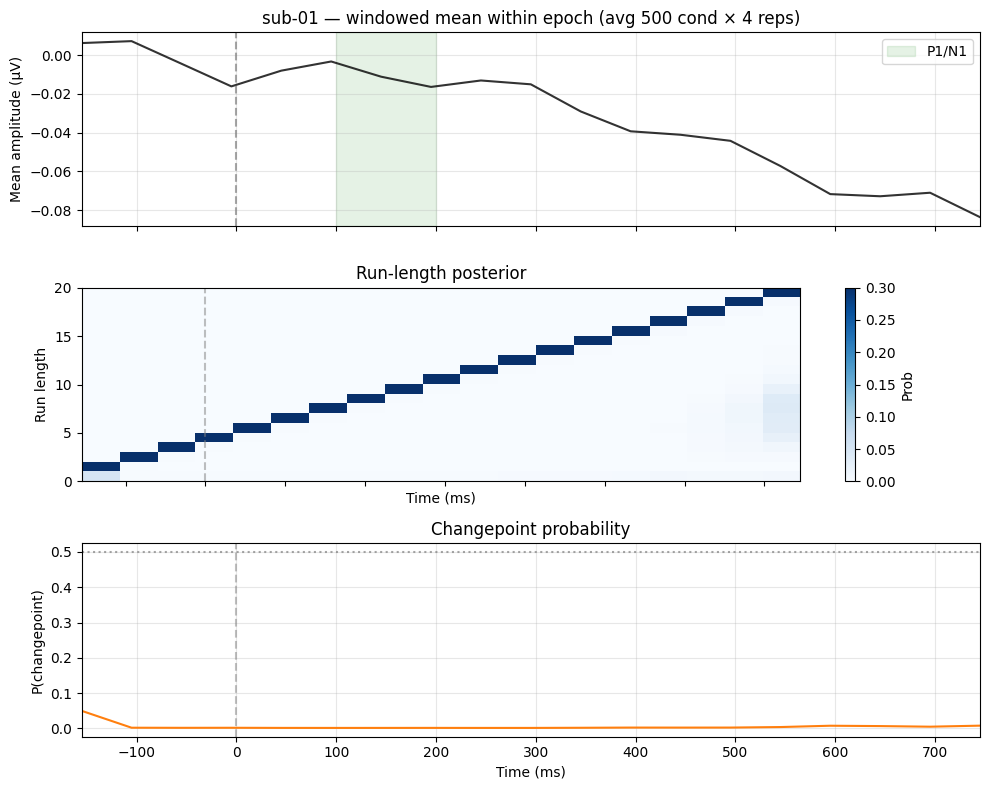

Saved bocpd__within_epoch__sub-01__2026-02-27.png


sub-02: 19 windows, mean=-0.050, std=0.039


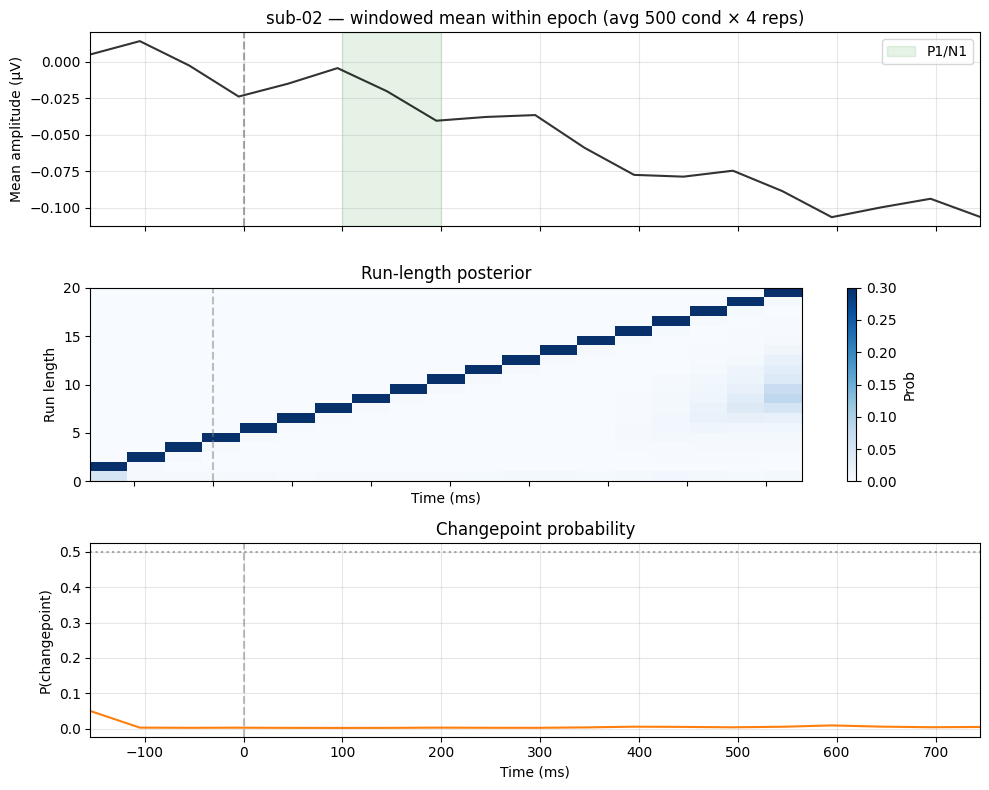

Saved bocpd__within_epoch__sub-02__2026-02-27.png


sub-03: 19 windows, mean=-0.065, std=0.064


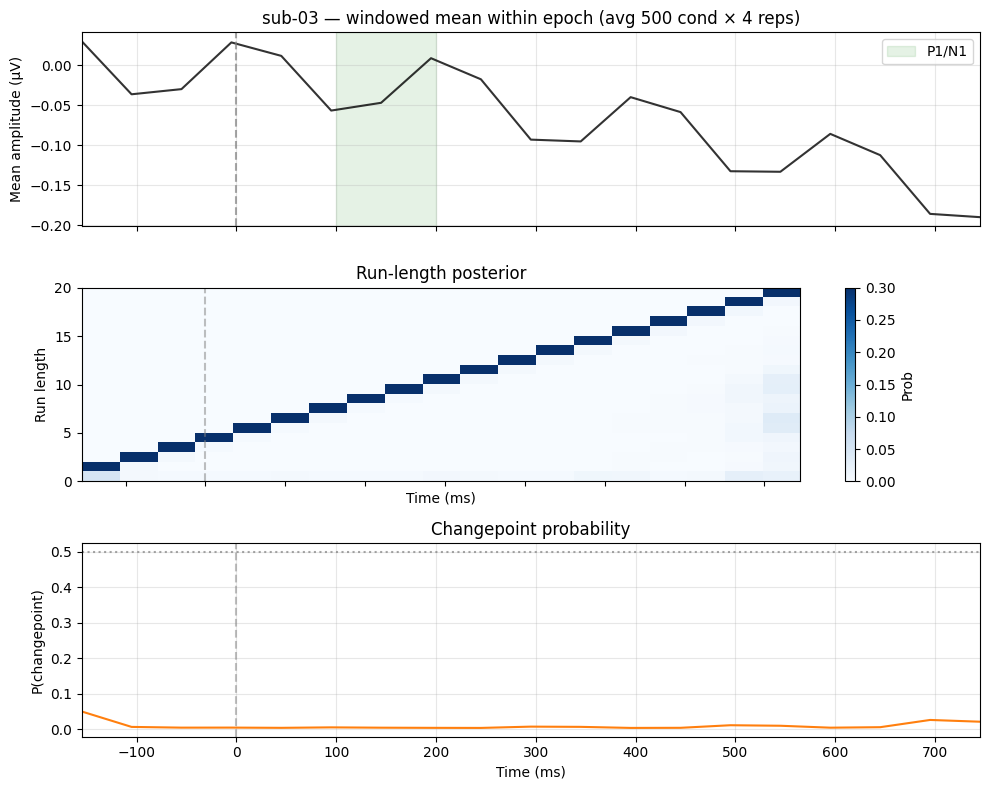

Saved bocpd__within_epoch__sub-03__2026-02-27.png


sub-04: 19 windows, mean=-0.094, std=0.080


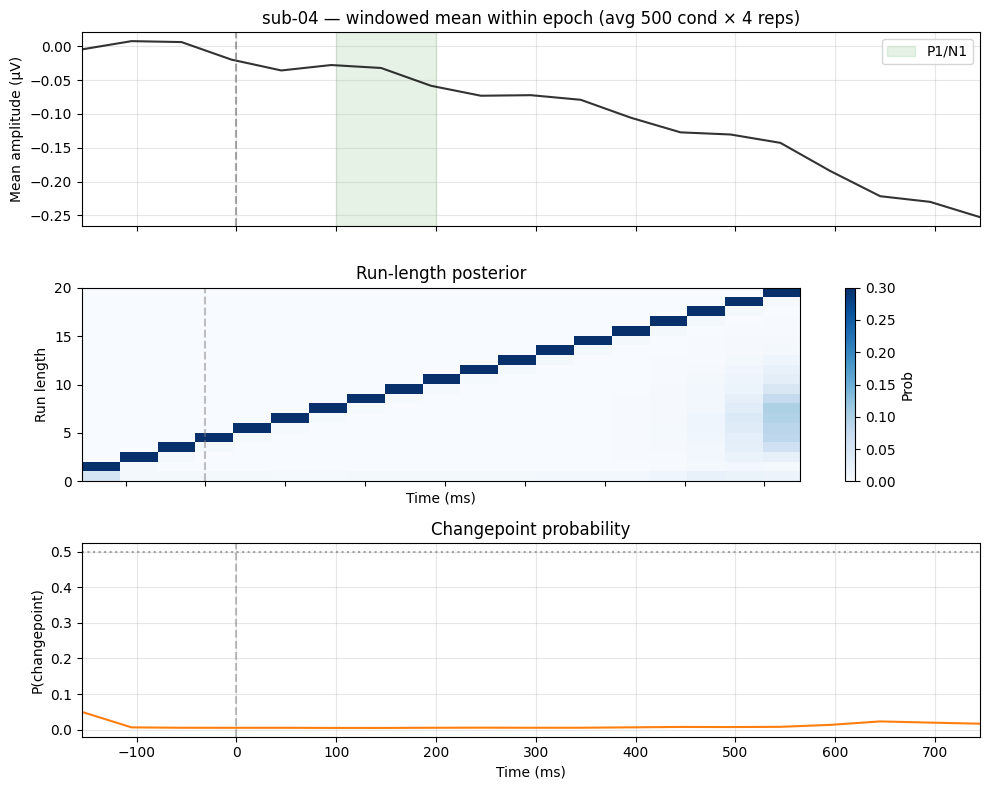

Saved bocpd__within_epoch__sub-04__2026-02-27.png


sub-05: 19 windows, mean=-0.058, std=0.053


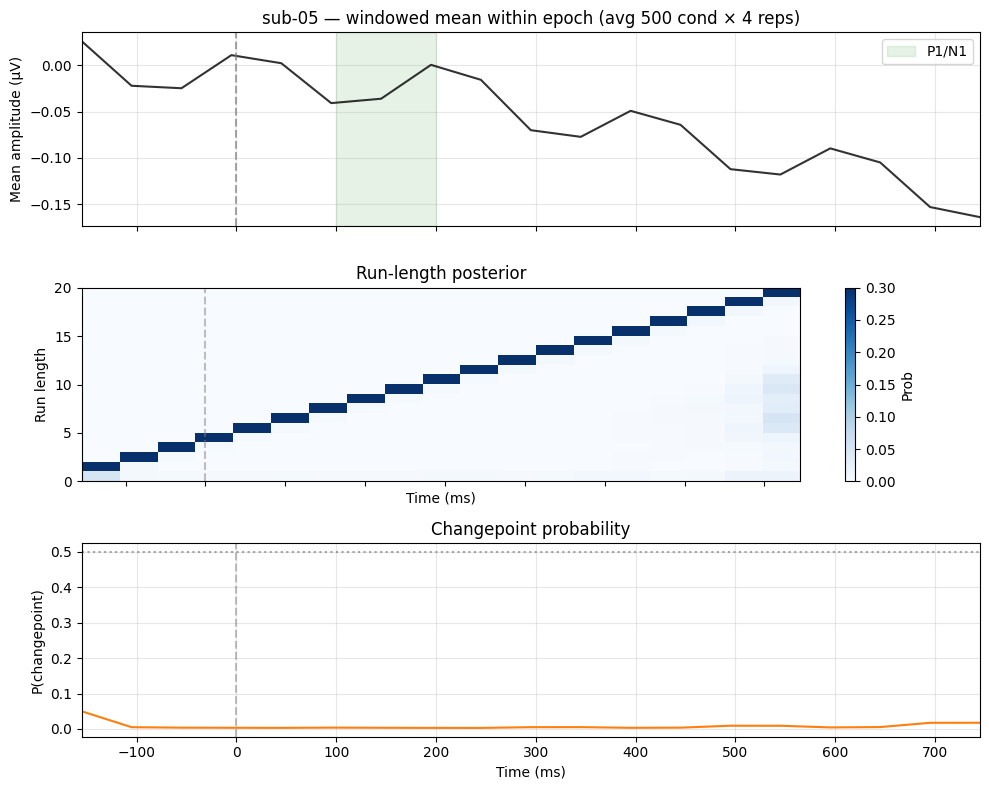

Saved bocpd__within_epoch__sub-05__2026-02-27.png


sub-06: 19 windows, mean=-0.026, std=0.030


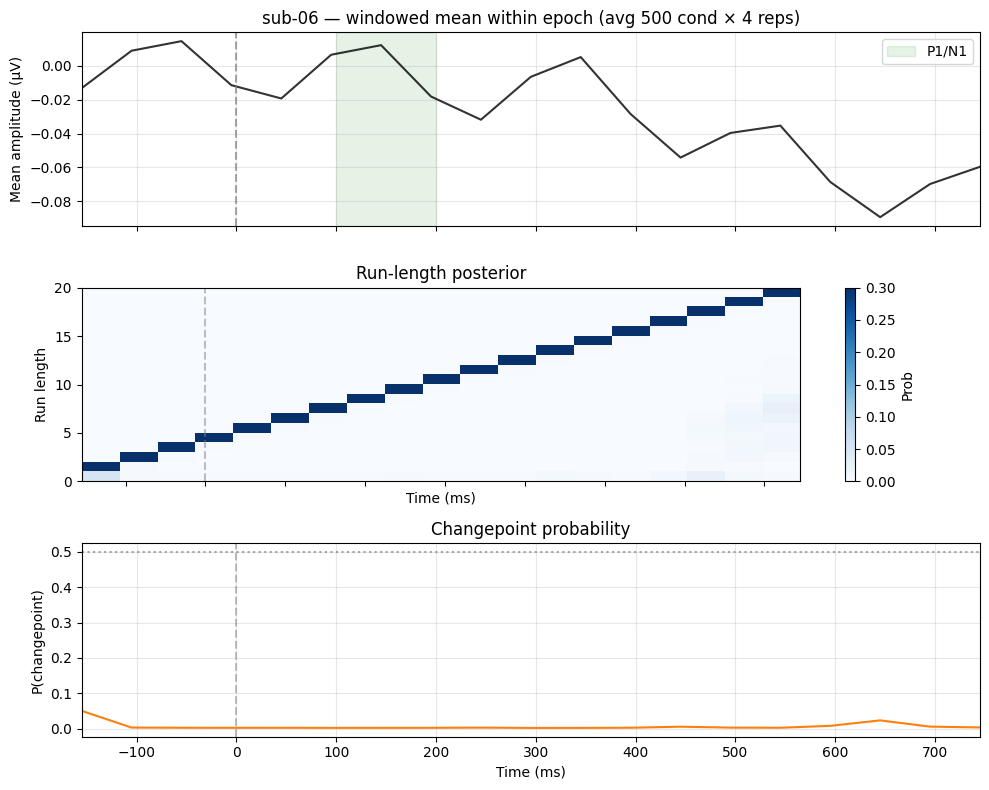

Saved bocpd__within_epoch__sub-06__2026-02-27.png


sub-07: 19 windows, mean=-0.030, std=0.032


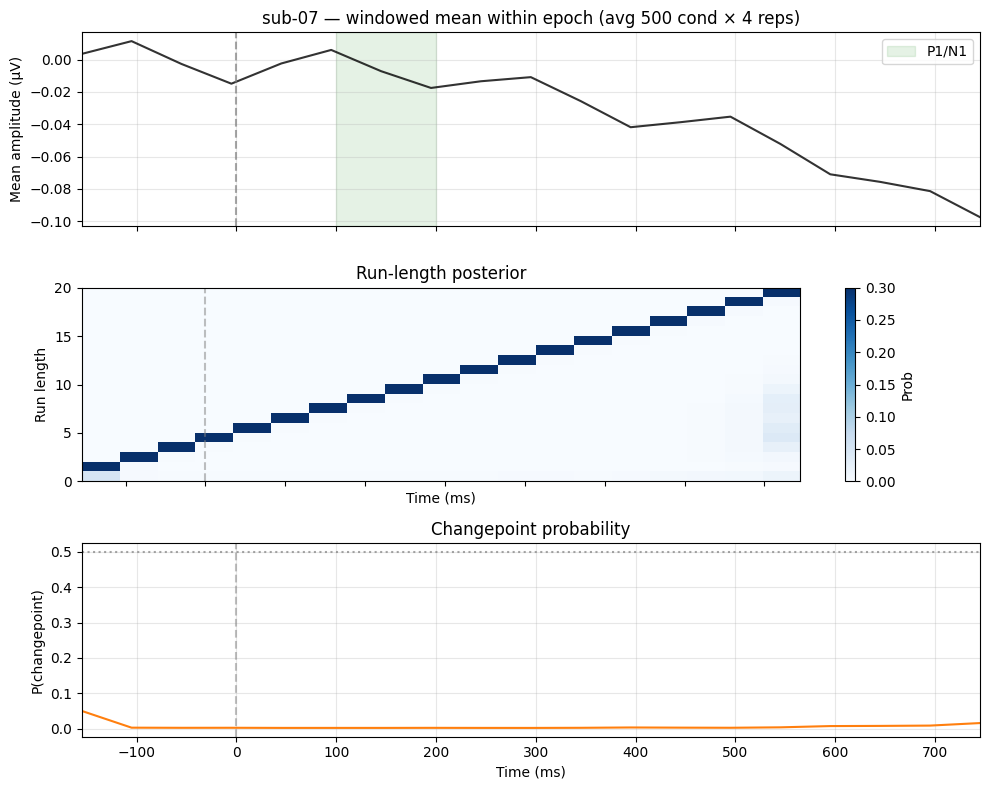

Saved bocpd__within_epoch__sub-07__2026-02-27.png


sub-08: 19 windows, mean=-0.082, std=0.063


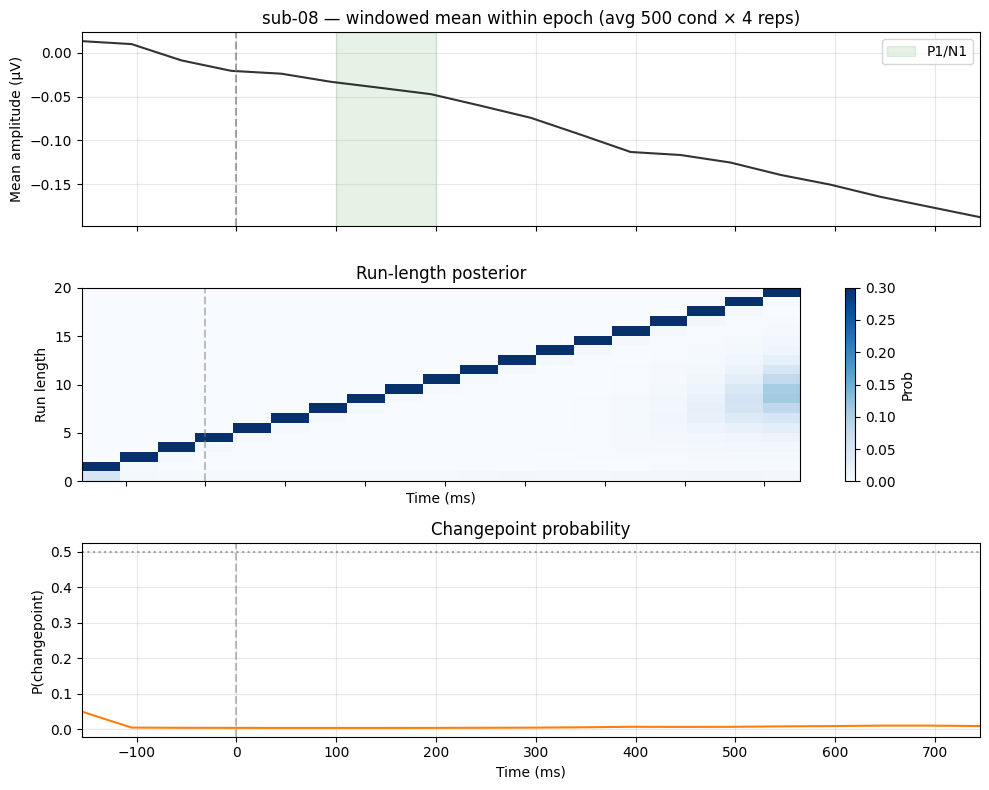

Saved bocpd__within_epoch__sub-08__2026-02-27.png


sub-09: 19 windows, mean=-0.030, std=0.036


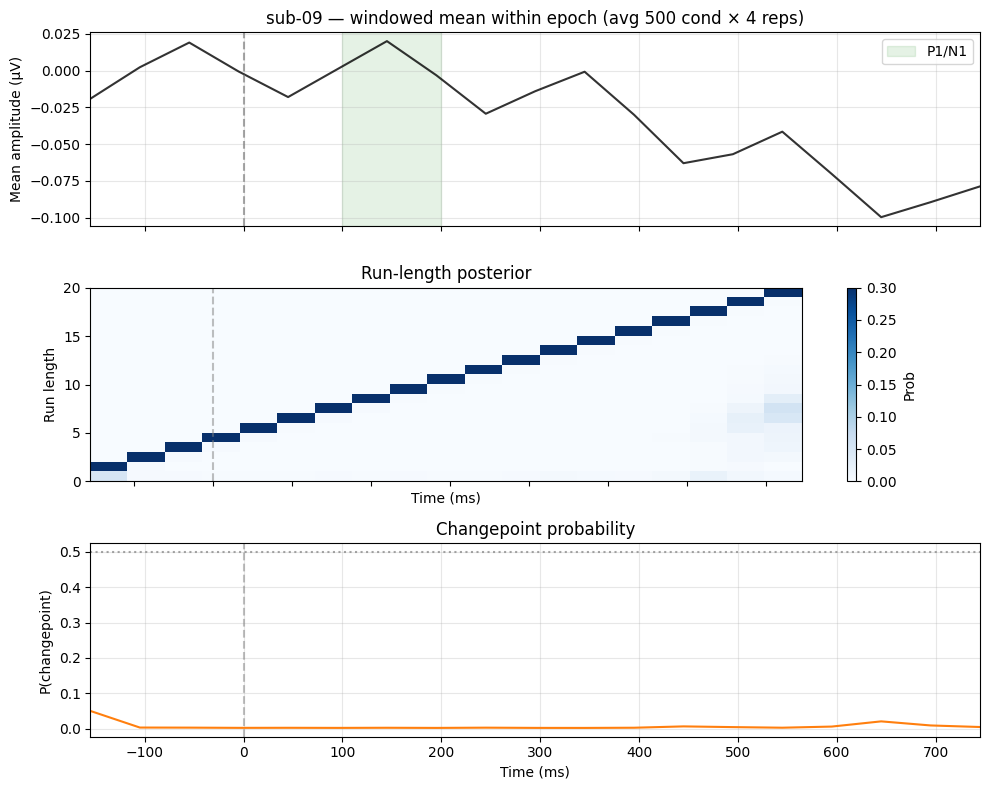

Saved bocpd__within_epoch__sub-09__2026-02-27.png


sub-10: 19 windows, mean=-0.052, std=0.052


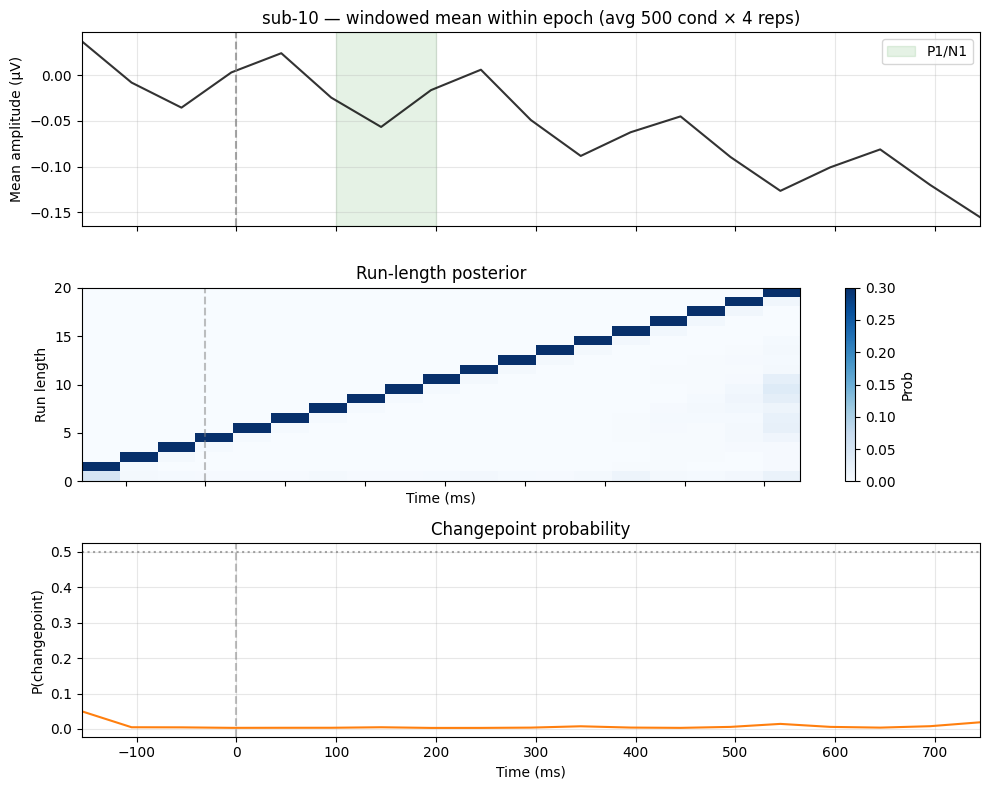

Saved bocpd__within_epoch__sub-10__2026-02-27.png


In [3]:
n_cond_sample = 500
np.random.seed(42)
# Save figures for all 10 participants
for sub in [f"sub-{i:02d}" for i in range(1, 11)]:
    p = DATA_ROOT / sub / "preprocessed_eeg_training.npy"
    if not p.exists():
        continue
    X, ch_names, times = load_preprocessed(p)
    cond_idx = np.random.choice(X.shape[0], size=min(n_cond_sample, X.shape[0]), replace=False)
    erp = X[cond_idx].mean(axis=(0, 1))
    x = windowed_mean(erp, WINDOW_SIZE, STRIDE)
    window_centers_ms = ((np.arange(len(x)) * STRIDE + (WINDOW_SIZE - 1) / 2) * 10) - 200
    R, cp_prob = bocpd_gaussian(x, hazard=0.05)
    print(f"{sub}: {len(x)} windows, mean={x.mean():.3f}, std={x.std():.3f}")
    # Plot and save figure
    fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
    axes[0].plot(window_centers_ms, x, "k-", alpha=0.8)
    axes[0].axvline(0, color="gray", ls="--", alpha=0.7)
    axes[0].axvspan(100, 200, alpha=0.1, color="green", label="P1/N1")
    axes[0].set_ylabel("Mean amplitude (µV)")
    axes[0].set_title(f"{sub} — windowed mean within epoch (avg {n_cond_sample} cond × 4 reps)")
    axes[0].legend(loc="upper right")
    axes[0].grid(True, alpha=0.3)
    im = axes[1].imshow(R.T[:, : len(x)], aspect="auto", origin="lower", cmap="Blues",
                        extent=[window_centers_ms[0], window_centers_ms[-1], 0, R.shape[1]], vmin=0, vmax=0.3)
    axes[1].axvline(0, color="gray", ls="--", alpha=0.5)
    axes[1].set_ylabel("Run length")
    axes[1].set_xlabel("Time (ms)")
    axes[1].set_title("Run-length posterior")
    plt.colorbar(im, ax=axes[1], label="Prob")
    axes[2].plot(window_centers_ms, cp_prob, "C1-", lw=1.5)
    axes[2].axvline(0, color="gray", ls="--", alpha=0.5)
    axes[2].axhline(0.5, color="gray", ls=":", alpha=0.7)
    axes[2].set_ylabel("P(changepoint)")
    axes[2].set_xlabel("Time (ms)")
    axes[2].set_title("Changepoint probability")
    axes[2].grid(True, alpha=0.3)
    plt.tight_layout()
    out_path = ARTIFACTS_FIG / f"bocpd__within_epoch__{sub}__2026-02-27.png"
    plt.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Saved {out_path.name}")

## Plot: windowed mean, run-length posterior, changepoint probability

In [4]:
# Figures saved in loop above for all 10 participants.

## Peak changepoint latency (all participants)

In [5]:
import pandas as pd
rows = []
for sub in [f"sub-{i:02d}" for i in range(1, 11)]:
    p = DATA_ROOT / sub / "preprocessed_eeg_training.npy"
    if not p.exists():
        continue
    X, _, _ = load_preprocessed(p)
    cond_idx = np.random.choice(X.shape[0], size=min(500, X.shape[0]), replace=False)
    erp = X[cond_idx].mean(axis=(0, 1))
    x = windowed_mean(erp, WINDOW_SIZE, STRIDE)
    window_centers_ms = ((np.arange(len(x)) * STRIDE + (WINDOW_SIZE - 1) / 2) * 10) - 200
    _, cp_prob = bocpd_gaussian(x, hazard=0.05)
    idx_max = np.argmax(cp_prob)
    rows.append({"participant": sub, "peak_cp_ms": float(window_centers_ms[idx_max]), "max_cp_prob": float(cp_prob.max())})
peak_df = pd.DataFrame(rows)
table_path = ROOT / "artifacts" / "tables" / "bocpd__within_epoch_peak_latency__2026-02-27.csv"
table_path.parent.mkdir(parents=True, exist_ok=True)
peak_df.to_csv(table_path, index=False)
print(peak_df.to_string(index=False))

participant  peak_cp_ms  max_cp_prob
     sub-01      -155.0         0.05
     sub-02      -155.0         0.05
     sub-03      -155.0         0.05
     sub-04      -155.0         0.05
     sub-05      -155.0         0.05
     sub-06      -155.0         0.05
     sub-07      -155.0         0.05
     sub-08      -155.0         0.05
     sub-09      -155.0         0.05
     sub-10      -155.0         0.05


## Lower hazard (0.01) to test sensitivity

Try hazard 0.01 instead of 0.05 to see if changepoint probability rises above prior.

In [6]:
rows_low = []
for sub in [f"sub-{i:02d}" for i in range(1, 11)]:
    p = DATA_ROOT / sub / "preprocessed_eeg_training.npy"
    if not p.exists():
        continue
    X, _, _ = load_preprocessed(p)
    cond_idx = np.random.choice(X.shape[0], size=min(500, X.shape[0]), replace=False)
    erp = X[cond_idx].mean(axis=(0, 1))
    x = windowed_mean(erp, WINDOW_SIZE, STRIDE)
    window_centers_ms = ((np.arange(len(x)) * STRIDE + (WINDOW_SIZE - 1) / 2) * 10) - 200
    _, cp_prob = bocpd_gaussian(x, hazard=0.01)
    idx_max = np.argmax(cp_prob)
    rows_low.append({"participant": sub, "peak_cp_ms": float(window_centers_ms[idx_max]), "max_cp_prob": float(cp_prob.max())})
low_df = pd.DataFrame(rows_low)
print("Hazard 0.01:")
print(low_df.to_string(index=False))
print(f"\nMean max_cp_prob (h=0.05): {peak_df['max_cp_prob'].mean():.3f}")
print(f"Mean max_cp_prob (h=0.01): {low_df['max_cp_prob'].mean():.3f}")
low_df.to_csv(ROOT / "artifacts" / "tables" / "bocpd__within_epoch_peak_latency_h001__2026-02-27.csv", index=False)

Hazard 0.01:
participant  peak_cp_ms  max_cp_prob
     sub-01      -155.0         0.01
     sub-02      -155.0         0.01
     sub-03      -155.0         0.01
     sub-04      -155.0         0.01
     sub-05      -155.0         0.01
     sub-06      -155.0         0.01
     sub-07      -155.0         0.01
     sub-08      -155.0         0.01
     sub-09      -155.0         0.01
     sub-10      -155.0         0.01

Mean max_cp_prob (h=0.05): 0.050
Mean max_cp_prob (h=0.01): 0.010
